In [5]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

In [6]:
df = pd.read_csv("data-export (1).csv")

In [7]:
print(df.head())

          # ----------------------------------------  \
0  Session primary channel group (Default channel...   
1                                             Direct   
2                                     Organic Social   
3                                             Direct   
4                                     Organic Social   

                 Unnamed: 1 Unnamed: 2 Unnamed: 3        Unnamed: 4  \
0  Date + hour (YYYYMMDDHH)      Users   Sessions  Engaged sessions   
1                2024041623        237        300               144   
2                2024041719        208        267               132   
3                2024041723        188        233               115   
4                2024041718        187        256               125   

                            Unnamed: 5                 Unnamed: 6  \
0  Average engagement time per session  Engaged sessions per user   
1                   47.526666666666700         0.6075949367088610   
2                    32.09737

In [8]:
df.columns = df.iloc[0]

df = df.drop(index=0).reset_index(drop=True)

In [9]:
df.columns = [

    "channel group",

    "DateHour",

    "Users",

    "Sessions",

    "Engaged Sessions",

    "Average engagement time per session",

    "Engaged sessions per user",

    "Events per session",

    "Engagement rate",

    "Event count"

]

In [10]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   channel group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged Sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB
None


In [12]:
df["DateHour"] = pd.to_datetime(

    df["DateHour"],

    format="%Y%m%d%H",

    errors='coerce'

)

In [13]:
numeric_cols = df.columns.drop(["channel group", "DateHour"])

df[numeric_cols] = df[numeric_cols].apply(

    pd.to_numeric,

    errors='coerce'

)

In [14]:
df["Hour"] = df["DateHour"].dt.hour

In [15]:
print(df.head())

print(df.info())

    channel group            DateHour  Users  Sessions  Engaged Sessions  \
0          Direct 2024-04-16 23:00:00    237       300               144   
1  Organic Social 2024-04-17 19:00:00    208       267               132   
2          Direct 2024-04-17 23:00:00    188       233               115   
3  Organic Social 2024-04-17 18:00:00    187       256               125   
4  Organic Social 2024-04-17 20:00:00    175       221               112   

   Average engagement time per session  Engaged sessions per user  \
0                            47.526667                   0.607595   
1                            32.097378                   0.634615   
2                            39.939914                   0.611702   
3                            32.160156                   0.668449   
4                            46.918552                   0.640000   

   Events per session  Engagement rate  Event count  Hour  
0            4.673333         0.480000         1402    23  
1       

In [16]:
print(df.describe())

                            DateHour        Users     Sessions  \
count                           3182  3182.000000  3182.000000   
mean   2024-04-20 01:17:07.278441216    41.935889    51.192646   
min              2024-04-06 00:00:00     0.000000     1.000000   
25%              2024-04-13 02:15:00    20.000000    24.000000   
50%              2024-04-20 02:00:00    42.000000    51.000000   
75%              2024-04-26 22:00:00    60.000000    71.000000   
max              2024-05-03 23:00:00   237.000000   300.000000   
std                              NaN    29.582258    36.919962   

       Engaged Sessions  Average engagement time per session  \
count       3182.000000                          3182.000000   
mean          28.325581                            66.644581   
min            0.000000                             0.000000   
25%           13.000000                            32.103034   
50%           27.000000                            49.020202   
75%           41.0000

 # SESIONS AND USER OVER TIME

In [22]:
sns.set(style="whitegrid")

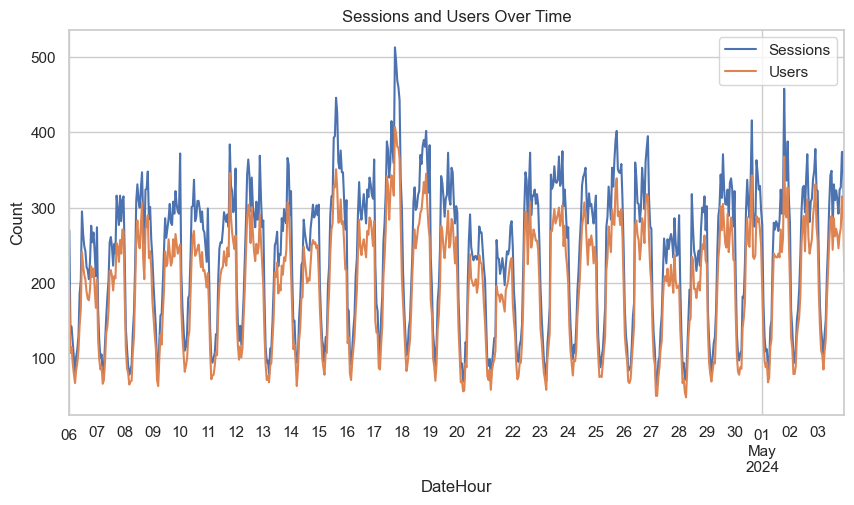

In [26]:
plt.figure(figsize=(10, 5))

df.groupby("DateHour")[["Sessions", "Users"]].sum().plot(ax=plt.gca())
plt.title("Sessions and Users Over Time")

plt.xlabel("DateHour")

plt.ylabel("Count")

plt.show()

/var/folders/3v/07cv5p9d0fj015vdpm6114100000gn/T/ipykernel_3237/3737295236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='channel group', ylabel='Users'>

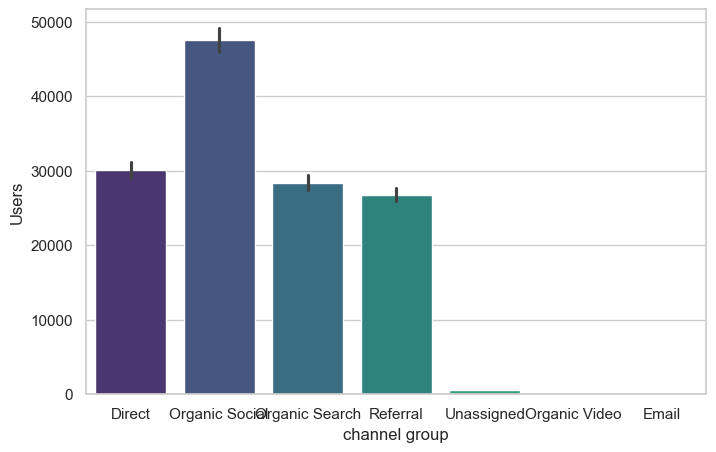

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(

    data=df,

    x="channel group",

    y="Users",

    estimator=np.sum,

    palette="viridis"

)

/var/folders/3v/07cv5p9d0fj015vdpm6114100000gn/T/ipykernel_3237/242610621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


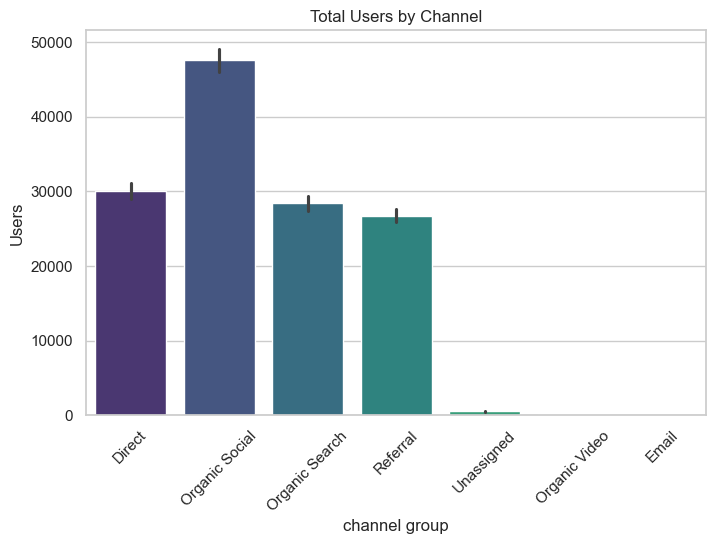

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(

    data=df,

    x="channel group",

    y="Users",

    estimator=np.sum,

    palette="viridis"

)

plt.title("Total Users by Channel")

plt.xticks(rotation=45)

plt.show()

## Average Engagement Time

/var/folders/3v/07cv5p9d0fj015vdpm6114100000gn/T/ipykernel_3237/645328315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


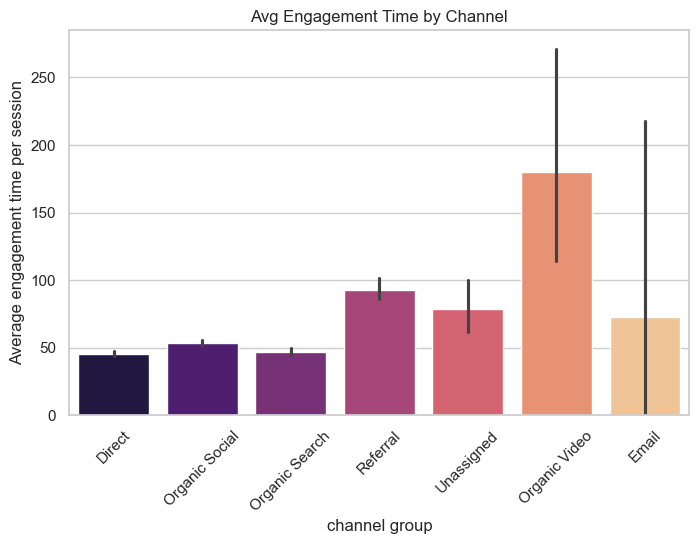

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(

    data=df,

    x="channel group",

    y="Average engagement time per session",

    estimator=np.mean,

    palette="magma"

)

plt.title("Avg Engagement Time by Channel")

plt.xticks(rotation=45)

plt.show()

# Engagement Rate Distribution by Channel

/var/folders/3v/07cv5p9d0fj015vdpm6114100000gn/T/ipykernel_3237/3053075725.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


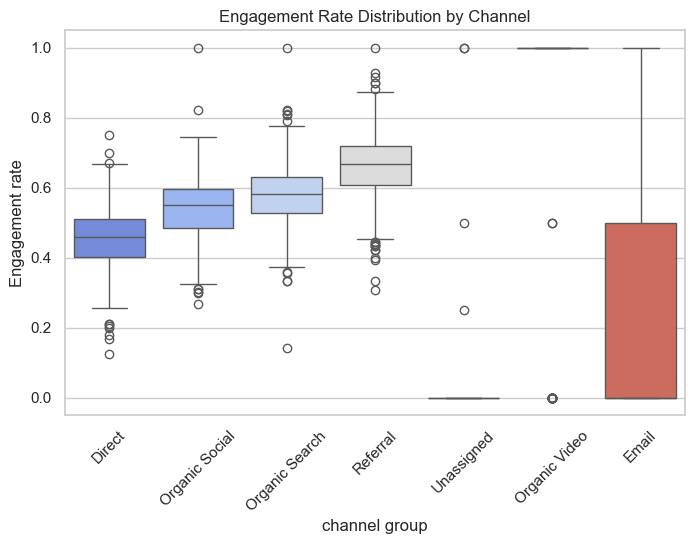

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(

    data=df,

    x="channel group",

    y="Engagement rate",

    palette="coolwarm"

)

plt.title("Engagement Rate Distribution by Channel")

plt.xticks(rotation=45)

plt.show()

# Engaged vs Non-Engaged Sessions

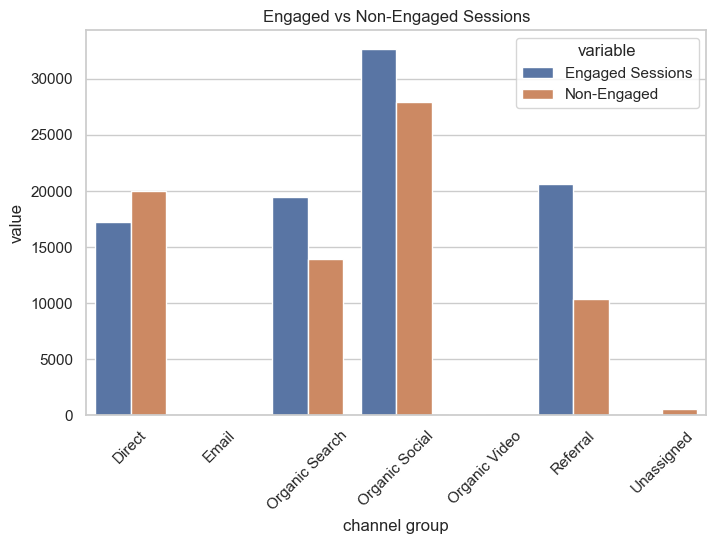

In [33]:


session_df = df.groupby("channel group")[

    ["Sessions", "Engaged Sessions"]

].sum()

session_df["Non-Engaged"] = (

    session_df["Sessions"] -

    session_df["Engaged Sessions"]

)

session_df = session_df.reset_index()

session_df_melted = session_df.melt(

    id_vars="channel group",

    value_vars=["Engaged Sessions", "Non-Engaged"]

)

plt.figure(figsize=(8, 5))

sns.barplot(

    data=session_df_melted,

    x="channel group",

    y="value",

    hue="variable"

)

plt.title("Engaged vs Non-Engaged Sessions")

plt.xticks(rotation=45)

plt.show()

## Traffic by Hour and Channel

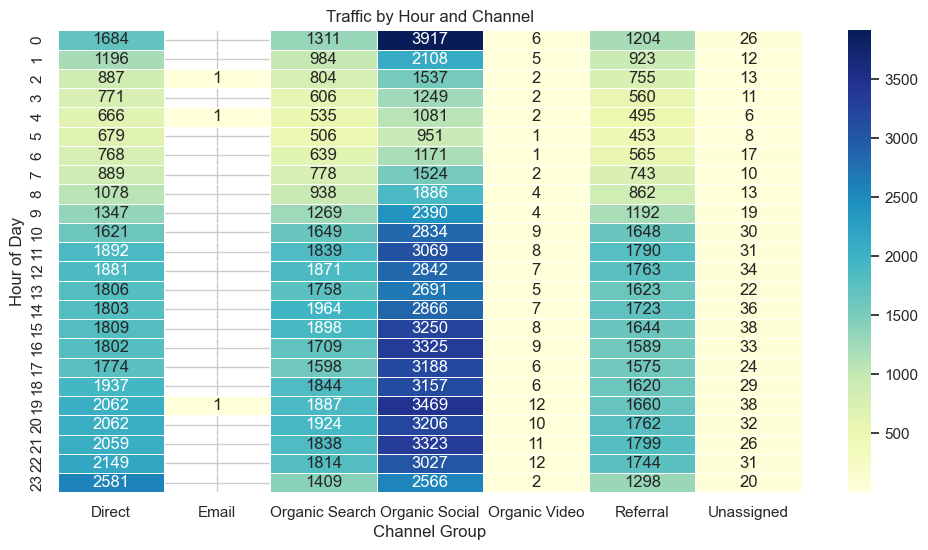

In [34]:
heatmap_data = df.groupby(

    ["Hour", "channel group"]

)["Sessions"].sum().unstack()

plt.figure(figsize=(12, 6))

sns.heatmap(

    heatmap_data,

    cmap="YlGnBu",

    linewidths=.5,

    annot=True,

    fmt=".0f"

)

plt.title("Traffic by Hour and Channel")

plt.xlabel("Channel Group")

plt.ylabel("Hour of Day")

plt.show()

# Engagement Rate vs Sessions Over Time

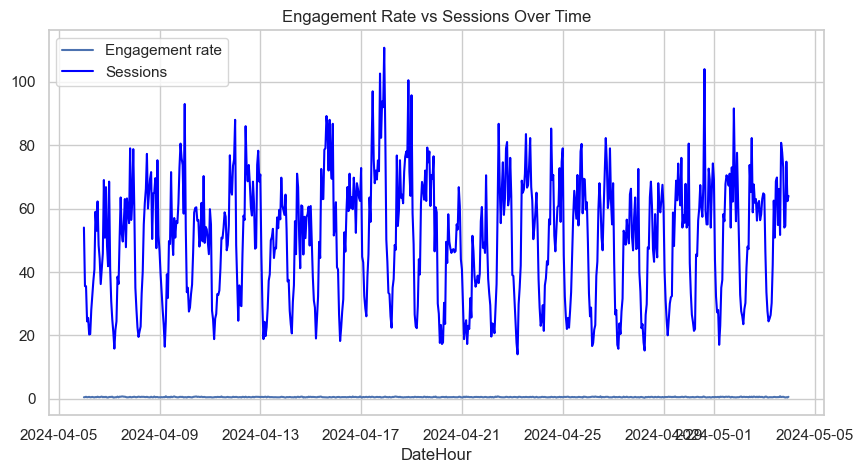

In [35]:
df_plot = df.groupby("DateHour")[

    ["Engagement rate", "Sessions"]

].mean().reset_index()

plt.figure(figsize=(10, 5))

plt.plot(

    df_plot["DateHour"],

    df_plot["Engagement rate"],

    label="Engagement rate"

)

plt.plot(

    df_plot["DateHour"],

    df_plot["Sessions"],

    label="Sessions",

    color="blue"

)

plt.title("Engagement Rate vs Sessions Over Time")

plt.xlabel("DateHour")

plt.legend()

plt.grid(True)

plt.show()